## **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

## **Load the Dataset**

In [3]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## **Explore the Dataset**

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


## **Data Cleaning**

In [12]:
if "Car_Name" in df.columns:
    df = df.drop("Car_Name", axis=1)

**Create Car Age feature.**

In [7]:
df["Car_Age"] = 2024 - df["Year"]
df = df.drop("Year", axis=1)

## **Convert Categorical Data**

In [14]:
df = pd.get_dummies(df, drop_first=True)

## **Data Visualization**

**Selling Price Distribution**

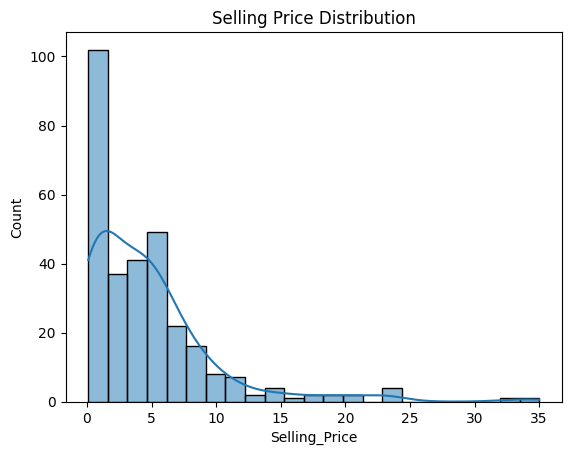

In [15]:
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Selling Price Distribution")
plt.show()

**Correlation Heatmap**

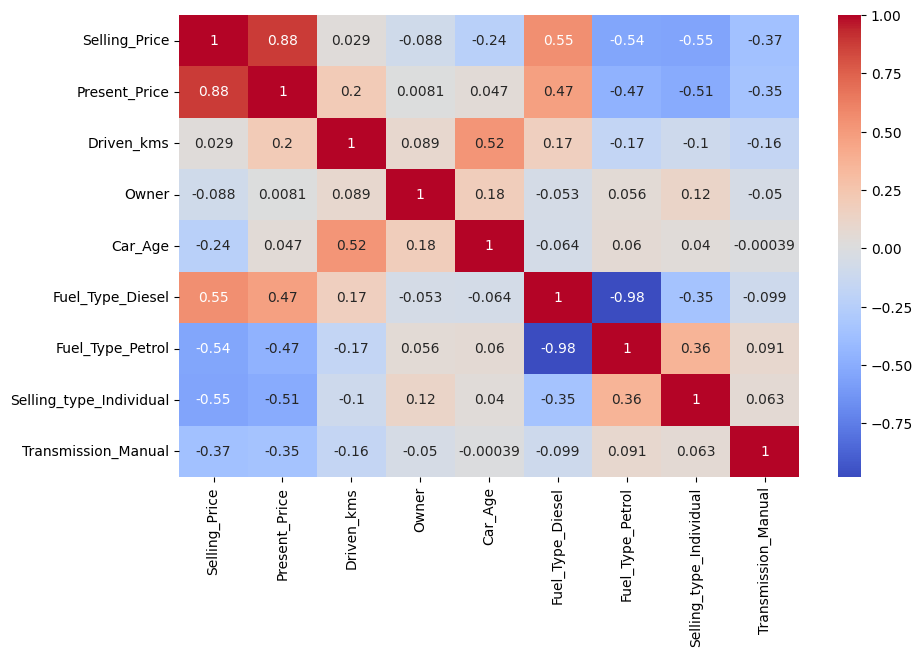

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

## **Prepare Data for Machine Learning**

In [17]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

## **Train-Test Split**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Train Machine Learning Model**

In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## **Make Predictions**

In [20]:
predictions = model.predict(X_test)

## **1) Model Evaluation**

In [21]:
print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 1.2163740193330348
R2 Score: 0.8488707839193155


## **2) Prediction Visualization**

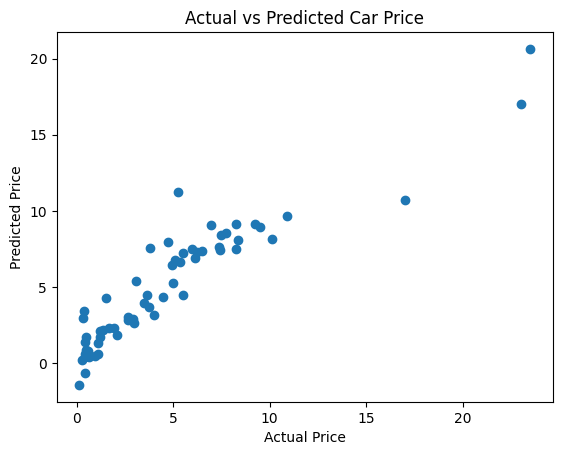

In [22]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()

## **Conclusion**

A machine learning model was developed to predict car selling prices using features such as fuel type, transmission, car age, and kilometers driven. The Linear Regression model showed good predictive performance and demonstrated how machine learning can be used in price estimation problems.